In [4]:
import os
import shutil

In [5]:

source = r"C:\Users\toy_3\OneDrive\เอกสาร\GitHub\NLP\kaggle.json"
destination = os.path.expanduser("~/.kaggle/kaggle.json")


os.makedirs(os.path.dirname(destination), exist_ok=True)
shutil.copyfile(source, destination)
os.chmod(destination, 0o600)



In [ ]:
#!kaggle competitions download -c nlp-getting-started

In [ ]:
#import zipfile

#with zipfile.ZipFile("nlp-getting-started.zip", "r") as zip_ref:
#    zip_ref.extractall("nlp_data")

# Load data

In [3]:
import pandas as pd

train_df = pd.read_csv("nlp_data/train.csv")
test_df = pd.read_csv("nlp_data/test.csv")

print("Training Set shape: {}".format(train_df.shape))
print("Test Set Shape: {}".format(test_df.shape))
print("{:.2f}".format(train_df.memory_usage().sum() / 1024**2))


Training Set shape: (7613, 5)
Test Set Shape: (3263, 4)
0.29


# Exploratory Data Analysis

In [4]:
print(train_df['text'].sample(5).values)

['#Myanmar  Displaced #Rohingya at #Sittwe point of no return http://t.co/cgf61fPmR0  #Prison like conditions #genocide IHHen MSF Refugees'
 'Mad River Complex fires have burned 14028 acres 8% contained: The Mad River Complex fires in Trinity County ... http://t.co/LfNIPpNOtO'
 'Lol meerkat is fucked. They will get demolished by periscope and Facebook live streaming.'
 'Love living on my own. I can blaze inside my apt or on the balcony'
 '#hot  Funtenna: hijacking computers to send data as sound waves [Black Hat 2015] http://t.co/s4PNIhJQX7 #prebreak #best']


In [5]:
#most Frequent words
from collections import Counter
import re

all_words = ' '.join(train_df["text"])
words = re.findall(r'\w+', all_words.lower())
common_words = Counter(words).most_common(20)

print(common_words) # คำเชื่อมในภาษาอังกฤษ ส่วนใหญ่

[('t', 5199), ('co', 4740), ('http', 4309), ('the', 3277), ('a', 2200), ('in', 1986), ('to', 1949), ('of', 1830), ('i', 1778), ('and', 1426), ('is', 950), ('s', 910), ('you', 902), ('for', 894), ('on', 860), ('it', 779), ('my', 680), ('that', 623), ('with', 572), ('at', 542)]


target
0    4342
1    3271
Name: count, dtype: int64


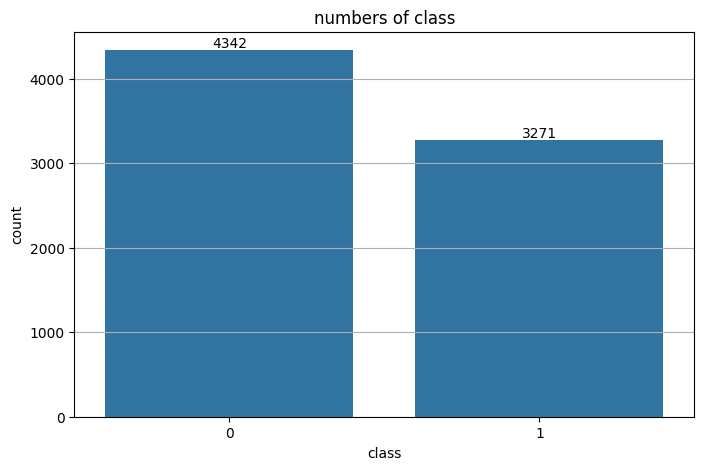

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

label_counts = train_df["target"].value_counts()
print(label_counts)

# bar chart
plt.figure(figsize = (8,5))
ax = sns.barplot(x=label_counts.index, y=label_counts.values)

for i, v in enumerate(label_counts.values):
    ax.text(i, v + 0.5, str(v), ha='center', va='bottom')
plt.title("numbers of class")
plt.xlabel("class")
plt.ylabel("count")
plt.grid(axis="y")
plt.show()

In [7]:
train_df["length"] = train_df["text"].apply(lambda x : len(x))
test_df["length"] = test_df["text"].apply(lambda x : len(x))

print("Train Length Stat :")
print(train_df["length"].describe())

print()

print("Test Length Stat :")
print(test_df["length"].describe())

Train Length Stat :
count    7613.000000
mean      101.037436
std        33.781325
min         7.000000
25%        78.000000
50%       107.000000
75%       133.000000
max       157.000000
Name: length, dtype: float64

Test Length Stat :
count    3263.000000
mean      102.108183
std        33.972158
min         5.000000
25%        78.000000
50%       109.000000
75%       134.000000
max       151.000000
Name: length, dtype: float64


# Preprocess Data

In [8]:
# Validation set
# Stafified split from Training Set
from sklearn.model_selection import train_test_split

x = train_df.drop(columns=["target"])
y = train_df["target"]

# train/validation
x_train, x_val, y_train, y_val = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42
)

train_split = x_train.copy()
train_split["target"] = y_train

val_split = x_val.copy()
val_split["target"] = y_val

print("New Train set :", train_split.shape)
print("Validation set :", val_split.shape)

New Train set : (6090, 6)
Validation set : (1523, 6)


In [18]:
from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    AutoConfig,

    Trainer,
    TrainingArguments
)

from datasets import (
    Dataset,
    DatasetDict,
    Features, Sequence, ClassLabel, Value
)

In [ ]:
import torch
target = list(set(train_df["target"].to_list()))

model_name = 'cardiffnlp/twitter-roberta-base-sentiment-latest'
config = AutoConfig.from_pretrained(model_name, num_labels = len(target))
tokennizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name,
                                                           config = config,
                                                           ignore_mismatched_sizes=True)

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([3, 768]) in the checkpo

In [ ]:
#!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118


In [9]:
print(test_df.columns)

Index(['id', 'keyword', 'location', 'text', 'length'], dtype='object')


In [10]:
print(val_split.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1523 entries, 4863 to 2344
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        1523 non-null   int64 
 1   keyword   1510 non-null   object
 2   location  998 non-null    object
 3   text      1523 non-null   object
 4   length    1523 non-null   int64 
 5   target    1523 non-null   int64 
dtypes: int64(3), object(3)
memory usage: 83.3+ KB
None


In [11]:
features = Features({
    "text": Value(dtype='string'),

    "target": ClassLabel(names=target)
})

train_df = train_split[["text", "target"]]
val_df = val_split[["text", "target"]]


d = DatasetDict({
    'train': Dataset.from_pandas(train_df, features=features, preserve_index=False),
    'dev': Dataset.from_pandas(val_df, features=features, preserve_index=False)
})

In [59]:
d

DatasetDict({
    train: Dataset({
        features: ['text', 'target'],
        num_rows: 6090
    })
    dev: Dataset({
        features: ['text', 'target'],
        num_rows: 1523
    })
})

In [60]:
d['train'][0]

{'text': 'Sassy city girl country hunk stranded in Smoky Mountain snowstorm #AoMS http://t.co/nkKcTttsD9 #ibooklove #bookboost',
 'target': 1}

In [23]:
def tokennize(examples):
    tokenized_inputs = tokennizer(examples["text"],
                                  is_split_into_words=False,
                                  truncation=True,
                                  max_length=100)
    return tokenized_inputs

tokenized_df = d.map(tokennize, batched=True)
tokenized_df["train"] = tokenized_df["train"].rename_column("target", "labels")
tokenized_df["dev"] = tokenized_df["dev"].rename_column("target", "labels")

Map: 100%|██████████| 1523/1523 [00:00<00:00, 40069.78 examples/s]


In [63]:
tokenized_df

DatasetDict({
    train: Dataset({
        features: ['text', 'target', 'input_ids', 'attention_mask'],
        num_rows: 6090
    })
    dev: Dataset({
        features: ['text', 'target', 'input_ids', 'attention_mask'],
        num_rows: 1523
    })
})

In [65]:
tokennizer.convert_ids_to_tokens(tokenized_df['train'][0]['input_ids'])

['<s>',
 'S',
 'assy',
 'Ġcity',
 'Ġgirl',
 'Ġcountry',
 'Ġh',
 'unk',
 'Ġstranded',
 'Ġin',
 'ĠSm',
 'oky',
 'ĠMountain',
 'Ġsnow',
 'storm',
 'Ġ#',
 'A',
 'o',
 'MS',
 'Ġhttp',
 '://',
 't',
 '.',
 'co',
 '/',
 'n',
 'k',
 'K',
 'c',
 'T',
 't',
 'ts',
 'D',
 '9',
 'Ġ#',
 'ib',
 'ook',
 'love',
 'Ġ#',
 'book',
 'boost',
 '</s>']

In [66]:
tokenized_df['train'][0]['input_ids']

[0,
 104,
 27633,
 343,
 1816,
 247,
 1368,
 6435,
 13202,
 11,
 4966,
 24878,
 4743,
 1958,
 10868,
 849,
 250,
 139,
 6222,
 2054,
 640,
 90,
 4,
 876,
 73,
 282,
 330,
 530,
 438,
 565,
 90,
 1872,
 495,
 466,
 849,
 1452,
 6576,
 17693,
 849,
 6298,
 33934,
 2]

In [20]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokennizer,
                                        padding=True,
                                        pad_to_multiple_of=8)

In [21]:
data_collator

DataCollatorWithPadding(tokenizer=RobertaTokenizerFast(name_or_path='cardiffnlp/twitter-roberta-base-sentiment-latest', vocab_size=50265, model_max_length=1000000000000000019884624838656, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	3: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	50264: AddedToken("<mask>", rstrip=False, lstrip=True, single_word=False, normalized=False, special=True),
}
), pad

In [14]:
import evaluate
import accelerate
print(accelerate.__version__)

1.6.0


# Train model

In [30]:
args = TrainingArguments(
    output_dir = './results',
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    eval_strategy='steps',
    eval_steps=20,
    logging_strategy="steps",
    logging_steps=20,
    save_strategy='steps',
    report_to='none'
)

import numpy as np
def compute_metrics(eval_preds):
    metric = evaluate.load("accuracy")
    logits, labels = eval_preds
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

trainer = Trainer(
    model,
    args,
    train_dataset = tokenized_df['train'],
    eval_dataset = tokenized_df['dev'],
    data_collator = data_collator,
    processing_class = tokennizer,
    compute_metrics = compute_metrics
)
trainer.train()

Step,Training Loss,Validation Loss,Accuracy
20,0.034500,1.277169,0.793171
40,0.017400,1.066297,0.812869
60,0.039300,1.160784,0.797768
80,0.045400,1.147488,0.788575
100,0.064900,0.996967,0.833880
120,0.030200,1.103358,0.824688
140,0.093800,1.159081,0.805647
160,0.117500,0.914580,0.831254
180,0.098900,1.054660,0.791858
200,0.139100,0.980107,0.793171


TrainOutput(global_step=285, training_loss=0.09404440354882625, metrics={'train_runtime': 264.7717, 'train_samples_per_second': 69.003, 'train_steps_per_second': 1.076, 'total_flos': 542321218419840.0, 'train_loss': 0.09404440354882625, 'epoch': 2.9763779527559056})

In [31]:
logs = pd.DataFrame(trainer.state.log_history)

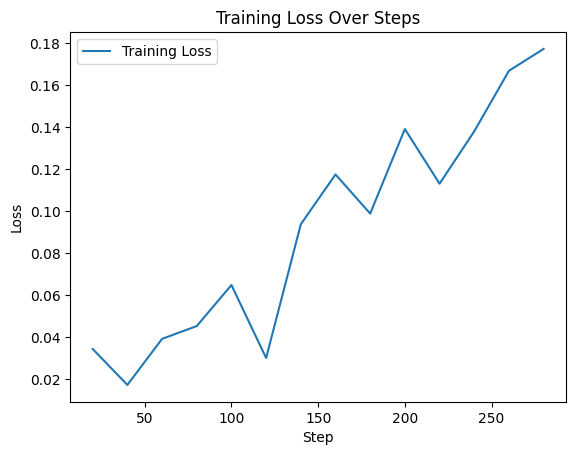

In [32]:
train_logs = logs.dropna(subset=['loss'])

plt.plot(train_logs['step'], train_logs['loss'], label='Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Loss Over Steps')
plt.legend()
plt.show()

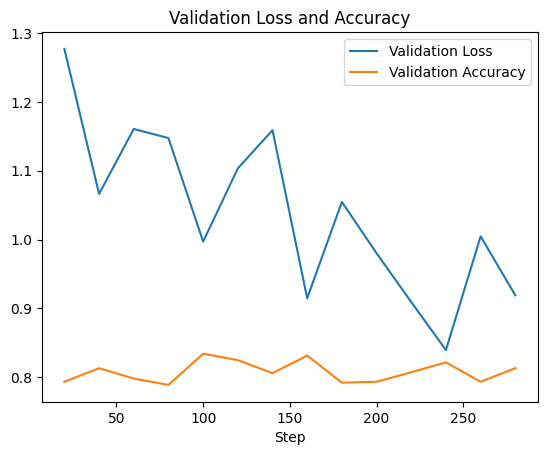

In [33]:
eval_logs = logs.dropna(subset=['eval_loss'])

plt.plot(eval_logs['step'], eval_logs['eval_loss'], label='Validation Loss')
plt.plot(eval_logs['step'], eval_logs['eval_accuracy'], label='Validation Accuracy')
plt.xlabel('Step')
plt.title('Validation Loss and Accuracy')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc

NameError: name 'logits' is not defined